In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score,fbeta_score, roc_curve, roc_auc_score, precision_recall_curve,auc, average_precision_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor, SGDClassifier, Ridge, Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.preprocessing import TargetEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from category_encoders import LeaveOneOutEncoder
from sklearn.ensemble import RandomForestRegressor
from scipy import stats ##

In [2]:
df = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\bmw.csv') 
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


In [3]:
'''df6=df.drop_duplicates(subset=None, keep='first', inplace=False, ignore_index=False)
df6'''

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


In [4]:
X = df.drop('price', axis=1)

In [5]:
y=df['price']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True)

In [7]:
## Находим категориальные столбцы
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

#Создаём encoder
encoder = LeaveOneOutEncoder(cols=cat_cols)

In [8]:
# Обучаем encoder только на train (как я понял чтобы не модель не брала данные из test)
X_train_enc = encoder.fit_transform(X_train, y_train)

# Преобразуем test
X_test_enc = encoder.transform(X_test)

In [9]:
X_test_enc

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
8728,15757.759875,2018,14609.297852,36469,21709.621290,150,50.4,1.5
761,22649.220118,2014,27378.582860,51565,21709.621290,160,51.4,2.0
7209,27630.310748,2019,27378.582860,8988,21709.621290,150,36.7,3.0
6685,19505.120361,2019,22351.619048,5054,24287.777411,145,39.2,1.5
8548,19505.120361,2018,14609.297852,13369,21709.621290,145,65.7,1.5
...,...,...,...,...,...,...,...,...
10677,19776.511236,2016,14609.297852,57918,21709.621290,125,58.9,2.0
8418,15757.759875,2016,14609.297852,55987,21709.621290,20,70.6,1.5
1702,19505.120361,2019,14609.297852,7710,21709.621290,145,60.1,2.0
6965,27630.310748,2020,27378.582860,4360,27485.882845,135,5.5,2.0


In [10]:
'''from sklearn.base import BaseEstimator, TransformerMixin


class MeanTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y):
        X = X.copy()
        df = X.copy()
        df[" target "] = y.values

        self.global_mean_ = y.mean()
        self.mapping_ = {}

        for col in self.cols:
            self.mapping_[col] = df.groupby(col)[" target "].mean().to_dict()

        return self

    def transform(self, X):
        X = X.copy()

        for col in self.cols:
            X[col] = X[col].map(self.mapping_[col])
            X[col] = X[col].fillna(self.global_mean_)

        return X

# Загружаем данные
df = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\bmw.csv')

target = "price"

# Признаки и цель
X = df.drop(columns=[target])
y = df[target]

# Кодируем нужные столбцы
encoder = MeanTargetEncoder(cols=["model", "transmission", "fuelType"])

X_train_enc = encoder.fit_transform(X_train, y_train)
X_test_enc = encoder.transform(X_test)'''




'from sklearn.base import BaseEstimator, TransformerMixin\n\n\nclass MeanTargetEncoder(BaseEstimator, TransformerMixin):\n    def __init__(self, cols):\n        self.cols = cols\n\n    def fit(self, X, y):\n        X = X.copy()\n        df = X.copy()\n        df[" target "] = y.values\n\n        self.global_mean_ = y.mean()\n        self.mapping_ = {}\n\n        for col in self.cols:\n            self.mapping_[col] = df.groupby(col)[" target "].mean().to_dict()\n\n        return self\n\n    def transform(self, X):\n        X = X.copy()\n\n        for col in self.cols:\n            X[col] = X[col].map(self.mapping_[col])\n            X[col] = X[col].fillna(self.global_mean_)\n\n        return X\n\n# Загружаем данные\ndf = pd.read_csv(\'C:\\Users\\User\\Documents\\ДЗ\\bmw.csv\')\n\ntarget = "price"\n\n# Признаки и цель\nX = df.drop(columns=[target])\ny = df[target]\n\n# Кодируем нужные столбцы\nencoder = MeanTargetEncoder(cols=["model", "transmission", "fuelType"])\n\nX_train_enc = encod

In [11]:
full_df = pd.concat([X_train_enc, y_train], axis=1)
z = full_df.apply(stats.zscore)
z.head()


,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
3652,-0.002672,0.816915,0.942571,-0.651978,1.097472,0.225809,-0.195461,-0.295106,0.115611
7007,2.075055,0.816915,-0.065240,-0.751929,-0.653570,0.225809,-0.605836,1.525610,2.108275
9045,-0.001350,-0.450641,-0.063030,1.536461,-0.649743,0.225809,-0.101753,1.525610,-0.671354
3910,4.231023,0.816915,-0.066492,-0.904976,3.159510,0.061840,2.738557,-1.205465,3.683255
3635,2.083840,-1.718196,-0.063388,1.510708,-0.650362,1.127640,-0.350563,1.525610,-0.221372


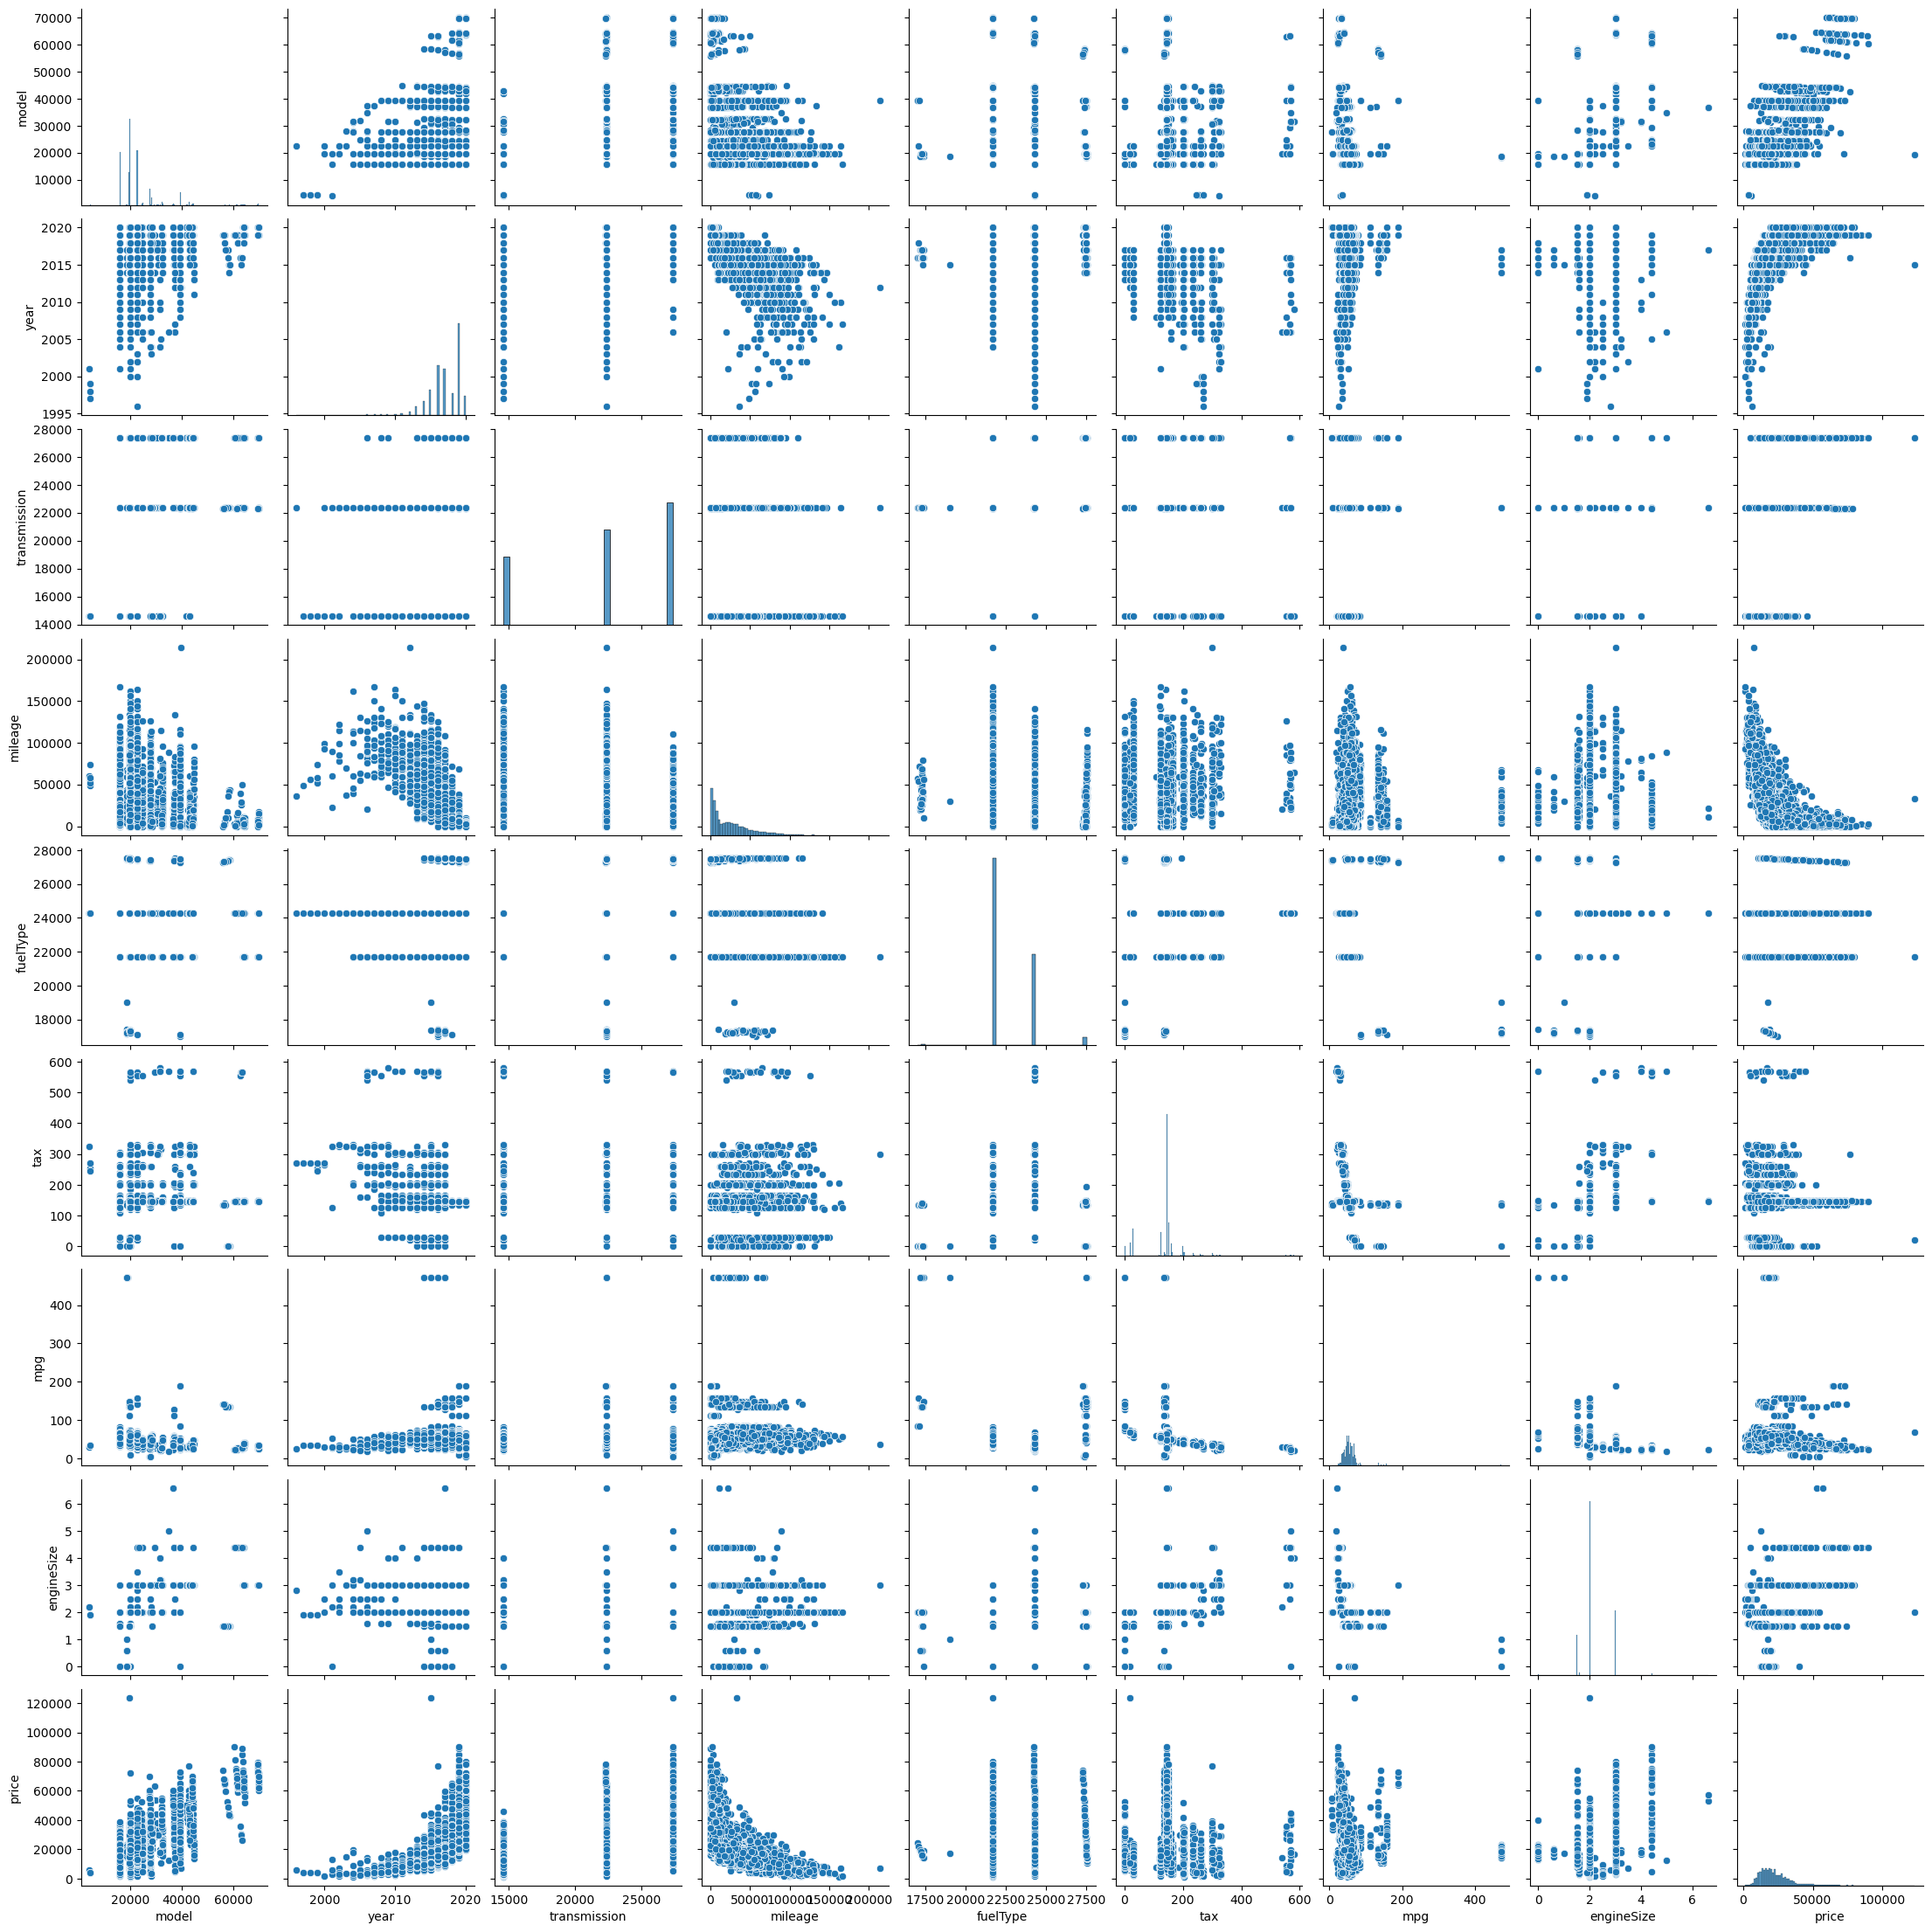

In [12]:
sns.pairplot(full_df)

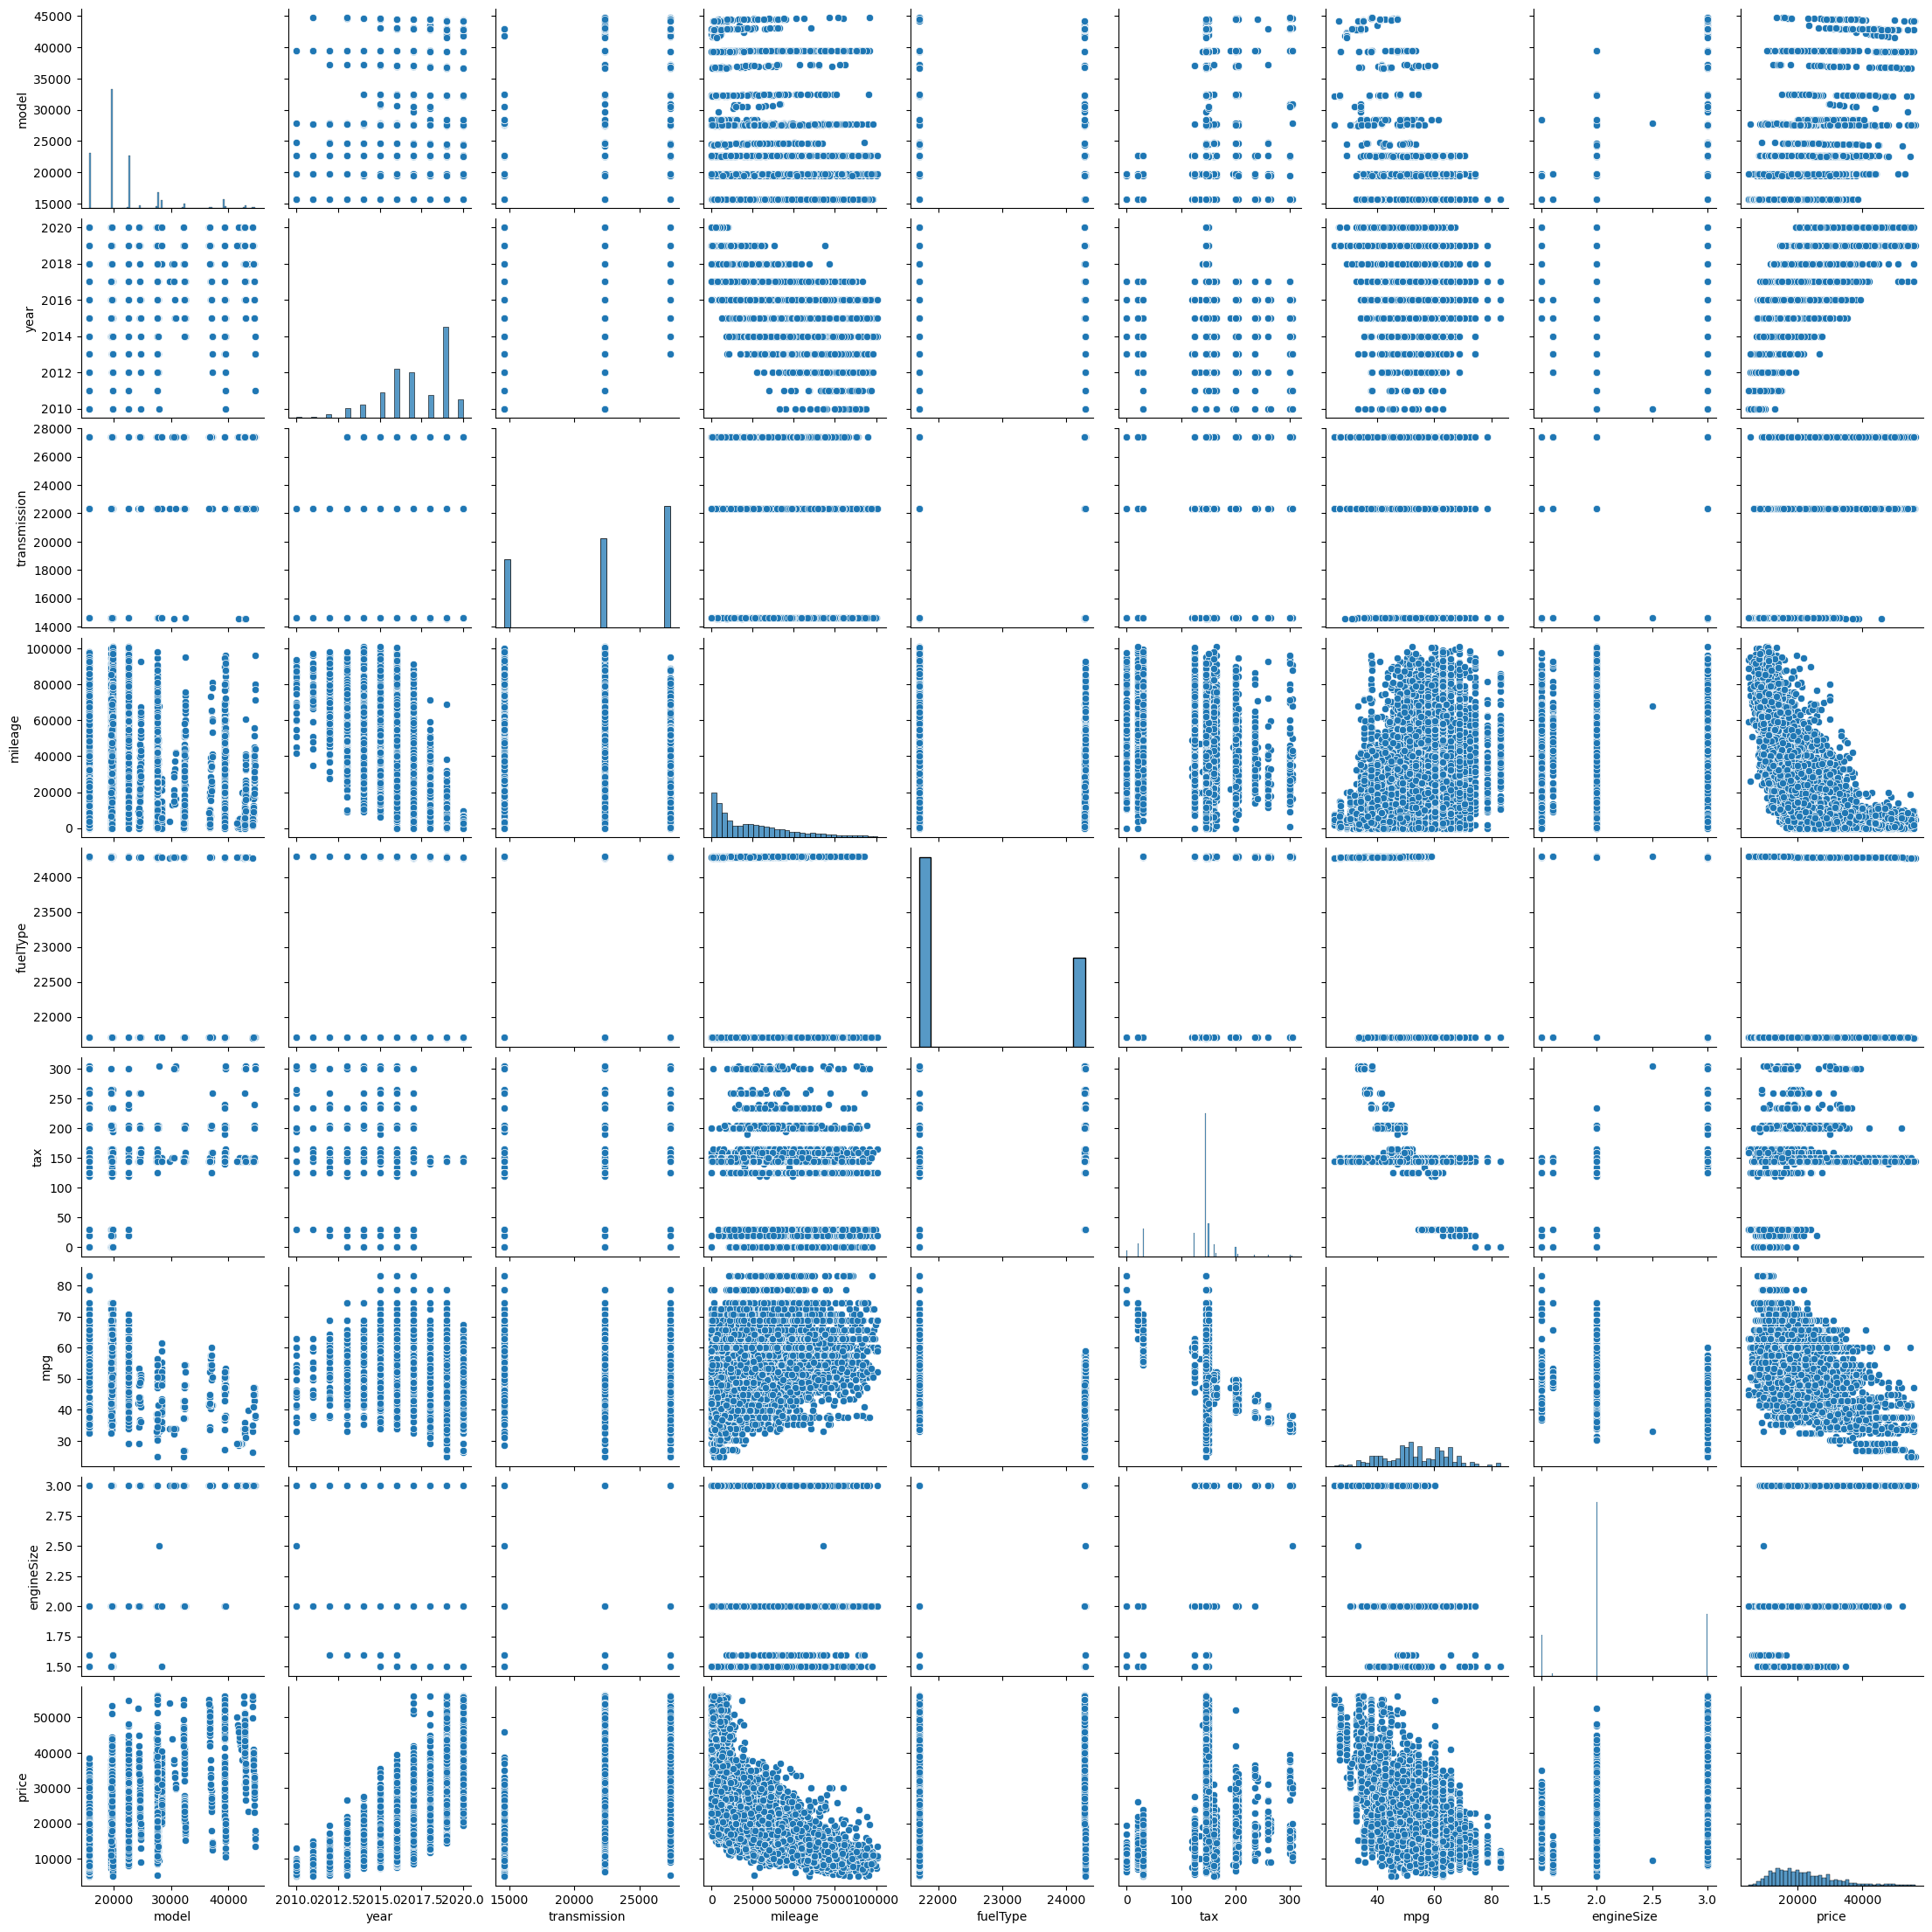

In [13]:
z_mask = (np.abs(z) < 3).all(axis = 1) ##удалим выбросы во всем датафрейме (есть хотя бы один False как следствие условия np.abs(z) < 3)
 
full_df1 = full_df[z_mask]
sns.pairplot(full_df1)

In [14]:
X = full_df1.drop('price', axis=1)

In [15]:
y=full_df1['price']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True)

In [17]:
# Обучаем модель
model = LinearRegression()

model.fit(X_train, y_train)

# Предсказание
y_pred = model.predict(X_test)

# Метрики
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 10787077.582233394
R2: 0.8777271123910857


In [18]:
model.coef_,model.intercept_ 

(array([ 4.94323671e-01,  2.07960740e+03,  9.57645048e-02, -9.65553404e-02,
        -1.46855811e+00, -2.19667662e+01, -3.00074121e+02,  3.03569496e+03]),
 np.float64(-4138078.960518888))

In [19]:
from sklearn.model_selection import cross_val_score

In [20]:
cross_val_score(model,X_train, y_train, cv=5).mean()

np.float64(0.8767810468077238)

In [21]:
## Подбор оптимальных гиперпараметров для линейной регрессии

In [22]:
from sklearn.linear_model import SGDRegressor

In [23]:
model1 = SGDRegressor(
    loss="squared_error",  ## Функция ошибки 
    penalty="l2", ## Регуляризация
    alpha=0.001,  ## Сила регуляризации
    learning_rate="invscaling", ## по мере обучения шаг уменьшается
    eta0=0.1, ## Начальный шаг обучения
    max_iter=5000,## макс. колво итераций
    tol=1e-4, ## допуск для остановки кода
    random_state=42
)

In [24]:
model1.fit(X_train, y_train)

# Предсказание
y_pred1 = model1.predict(X_test)

# Метрики
print("MSE:", mean_squared_error(y_test, y_pred1))
print("R2:", r2_score(y_test, y_pred1))

MSE: 2.352367470790304e+37
R2: -2.666438256127353e+29


In [25]:
print('Оптимальные гиперпараметры',model1.best_params_)

AttributeError: 'SGDRegressor' object has no attribute 'best_params_'

In [26]:
## Обучаем случайным лесом

In [27]:
model2 = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print("MSE:",  mean_squared_error(y_test, y_pred2))
print("R2:", r2_score(y_test, y_pred2))

MSE: 108926.07020750245
R2: 0.9987653092286924


In [28]:
cross_val_score(model2,X_train, y_train, cv=5).mean()

np.float64(0.9978006401099752)

In [29]:
## Оценка наиболее важных параметров для модели
importances = pd.Series(model2.feature_importances_, index=X_train_enc.columns)
print(importances.sort_values(ascending=False).head(10))

year            0.469068
fuelType        0.223574
model           0.106122
engineSize      0.095994
mpg             0.057213
transmission    0.026192
mileage         0.013608
tax             0.008230
dtype: float64


In [30]:
## Подбор гиперпараметров случайного леса 
from sklearn.model_selection import GridSearchCV 

In [166]:
## Подбор гиперпараметров 
##Сетка параметров
param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 5, 10, 15, 20],
    "max_features": ["sqrt", "log2", ],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
}

##Поиск лучших параметров
grid = GridSearchCV(
    estimator=model2,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

In [167]:
grid.fit(X_train_enc, y_train)

Fitting 5 folds for each of 640 candidates, totalling 3200 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [168]:
grid.best_params_

{'max_depth': None,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

## Итого по результатам обуччения двух моделей лучше предсказывает модель случайного леса (это показывают метрики MAE, R2, а также результаты кроссвалидации)
## наиболее влияющую на таргет параметры оказались год , молеь и пробег машины

In [31]:
##Уровень 2

In [110]:
bmw = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\bmw.csv') 
audi = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\audi.csv')  
ford = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\ford.csv')
hyundi = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\hyundi.csv')
skoda = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\skoda.csv')
toyota = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\toyota.csv')
cclass = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\cclass.csv')
focus = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\focus.csv')
merc = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\merc.csv')
vw = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\vw.csv')
vauxhall = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\vauxhall.csv')

In [111]:
## объединяем все в один датафрейм
df2 = pd.concat([bmw,audi,ford,hyundi,skoda,toyota,cclass,focus,merc,vw,vauxhall],axis=0,ignore_index=True)
df2

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,tax(£)
0,5 Series,2014,11200,Automatic,67068,Diesel,125.0,57.6,2.0,NaN
1,6 Series,2018,27000,Automatic,14827,Petrol,145.0,42.8,2.0,NaN
2,5 Series,2016,16000,Automatic,62794,Diesel,160.0,51.4,3.0,NaN
3,1 Series,2017,12750,Automatic,26676,Diesel,145.0,72.4,1.5,NaN
4,7 Series,2014,14500,Automatic,39554,Diesel,160.0,50.4,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...
108535,Tigra,2007,2499,Manual,48640,Petrol,165.0,46.3,1.4,NaN
108536,Vectra,2007,1795,Manual,75000,Petrol,240.0,39.2,1.8,NaN
108537,Vectra,2005,1495,Manual,74000,Petrol,235.0,38.7,1.8,NaN
108538,Vectra,2008,1695,Automatic,131000,Diesel,200.0,39.8,1.9,NaN


In [112]:
df2.isna().sum()

model                0
year                 0
price                0
transmission         0
mileage              0
fuelType             0
tax              14213
mpg               9353
engineSize           0
tax(£)          103680
dtype: int64

In [113]:
df2['tax']=df2['tax'].fillna(df2['tax(£)']*100/73) ## Видно что указан налог либо в фунтах дибо в долларах - не придумал ничего лучше чем сделать просто один стобец переведя фунты в доллары
df2.isna().sum() 



model                0
year                 0
price                0
transmission         0
mileage              0
fuelType             0
tax               9353
mpg               9353
engineSize           0
tax(£)          103680
dtype: int64

In [114]:
df2.drop(['tax(£)'], axis=1, inplace=True)

In [115]:
df2.isna().sum()

model              0
year               0
price              0
transmission       0
mileage            0
fuelType           0
tax             9353
mpg             9353
engineSize         0
dtype: int64

In [116]:
miss_df=df2[df2.isna().any(axis=1)]
miss_df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
57279,C Class,2020,30495,Automatic,1200,Diesel,NaN,NaN,2.0
57280,C Class,2020,29989,Automatic,1000,Petrol,NaN,NaN,1.5
57281,C Class,2020,37899,Automatic,500,Diesel,NaN,NaN,2.0
57282,C Class,2019,30399,Automatic,5000,Diesel,NaN,NaN,2.0
57283,C Class,2019,29899,Automatic,4500,Diesel,NaN,NaN,2.0
...,...,...,...,...,...,...,...,...,...
66627,Focus,2019,18745,Manual,7855,Diesel,NaN,NaN,2.0
66628,Focus,2019,16350,Manual,13891,Petrol,NaN,NaN,1.0
66629,Focus,2019,16850,Manual,13452,Petrol,NaN,NaN,1.0
66630,Focus,2019,17310,Automatic,13376,Petrol,NaN,NaN,1.0


In [117]:
miss_df['model'].unique()

array([' C Class', ' Focus'], dtype=object)

In [118]:
res=df2[df2['model']==' C Class']
res

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
57279,C Class,2020,30495,Automatic,1200,Diesel,NaN,NaN,2.0
57280,C Class,2020,29989,Automatic,1000,Petrol,NaN,NaN,1.5
57281,C Class,2020,37899,Automatic,500,Diesel,NaN,NaN,2.0
57282,C Class,2019,30399,Automatic,5000,Diesel,NaN,NaN,2.0
57283,C Class,2019,29899,Automatic,4500,Diesel,NaN,NaN,2.0
...,...,...,...,...,...,...,...,...,...
79738,C Class,2019,27999,Automatic,6537,Petrol,145.0,44.1,2.0
79739,C Class,2019,24999,Automatic,6064,Diesel,145.0,61.4,2.0
79744,C Class,2019,30399,Automatic,5000,Diesel,145.0,61.4,2.0
79745,C Class,2020,30999,Automatic,1000,Diesel,145.0,64.2,2.0


In [119]:
merc

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,SLK,2005,5200,Automatic,63000,Petrol,325,32.1,1.8
1,S Class,2017,34948,Automatic,27000,Hybrid,20,61.4,2.1
2,SL CLASS,2016,49948,Automatic,6200,Petrol,555,28.0,5.5
3,G Class,2016,61948,Automatic,16000,Petrol,325,30.4,4.0
4,G Class,2016,73948,Automatic,4000,Petrol,325,30.1,4.0
...,...,...,...,...,...,...,...,...,...
13114,C Class,2020,35999,Automatic,500,Diesel,145,55.4,2.0
13115,B Class,2020,24699,Automatic,2500,Diesel,145,55.4,2.0
13116,GLC Class,2019,30999,Automatic,11612,Diesel,145,41.5,2.1
13117,CLS Class,2019,37990,Automatic,2426,Diesel,145,45.6,2.0


In [120]:
## Видим, что  пропущенные значения Nan есть только в марках merc и focus при чем не вовсех столбцах -> можно заменить на средние значения имеющихся данных в этих марках

In [121]:
df2['tax']=df2['tax'].fillna(df2.groupby(['model', 'year'])['tax'].transform('median'))
df2['mpg']=df2['mpg'].fillna(df2.groupby(['model', 'year'])['mpg'].transform('median'))

In [122]:
df2.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             5
mpg             5
engineSize      0
dtype: int64

In [123]:
miss_df2=df2[df2.isna().any(axis=1)]
miss_df2

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
60736,C Class,1991,4450,Automatic,170000,Petrol,NaN,NaN,3.0
60791,C Class,1995,4750,Automatic,173000,Petrol,NaN,NaN,3.6
60892,C Class,2003,1795,Automatic,88082,Diesel,NaN,NaN,2.1
61039,C Class,1998,1290,Automatic,140000,Petrol,NaN,NaN,2.0
66383,Focus,2002,795,Manual,101000,Petrol,NaN,NaN,1.6


In [124]:
## Не знаю прочему эти столбцы не приняли средние ззначения -решил просто удалить ибо 5 значений  в таком большом датасете не должны сильно повлиять на прогноз
df2=df2.dropna()
df2

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125.0,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145.0,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160.0,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145.0,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160.0,50.4,3.0
...,...,...,...,...,...,...,...,...,...
108535,Tigra,2007,2499,Manual,48640,Petrol,165.0,46.3,1.4
108536,Vectra,2007,1795,Manual,75000,Petrol,240.0,39.2,1.8
108537,Vectra,2005,1495,Manual,74000,Petrol,235.0,38.7,1.8
108538,Vectra,2008,1695,Automatic,131000,Diesel,200.0,39.8,1.9


In [125]:
from catboost import CatBoostRegressor

In [126]:
X = df2.drop('price', axis=1)

In [127]:
y=df2['price']

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True)

In [129]:
cat_features2 = X_train.select_dtypes(include=['object']).columns.tolist()

In [130]:
cat_features2

['model', 'transmission', 'fuelType']

In [131]:
model3 = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.5,
    depth=8,
    loss_function='MAE',
    random_seed=42,
    verbose=100
)

In [132]:
model3.fit(
    X_train, y_train,
    cat_features=cat_features2)

0:	learn: 4459.3478073	total: 41ms	remaining: 41s
100:	learn: 1285.4952494	total: 3.34s	remaining: 29.7s
200:	learn: 1168.9919658	total: 6.91s	remaining: 27.5s
300:	learn: 1122.5182320	total: 10.2s	remaining: 23.6s
400:	learn: 1095.0983898	total: 13.4s	remaining: 20s
500:	learn: 1081.4237927	total: 16.6s	remaining: 16.6s
600:	learn: 1071.2882559	total: 19.8s	remaining: 13.2s
700:	learn: 1060.0669960	total: 23.3s	remaining: 9.95s
800:	learn: 1052.9488532	total: 26.7s	remaining: 6.62s
900:	learn: 1044.3678500	total: 30s	remaining: 3.3s
999:	learn: 1037.0910489	total: 33.3s	remaining: 0us


CatBoostRegressor(depth=8, iterations=1000, learning_rate=0.5, loss_function='MAE', random_seed=42, verbose=100)

In [133]:
## Делаем прогноз
y_pred = model3.predict(X_test)

## Считаем метрики
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 6139812.4768199
R2: 0.9343964205054984


In [134]:
## Пробуем обучить через CatBoostEncoder

In [135]:
from category_encoders import CatBoostEncoder
cat_features = df2[["model", "transmission", "fuelType"]]
encoder = CatBoostEncoder(cols=cat_features)

In [136]:
# Кодируем только train
X_train_enc1 = encoder.fit_transform(X_train, y_train)
X_test_enc1 = encoder.transform(X_test)

# Обучаем модель
model4 = RandomForestRegressor(random_state=42)
model4.fit(X_train_enc1, y_train)

# Предсказание
y_pred_enc = model4.predict(X_test_enc1)
r2_enc = r2_score(y_test, y_pred_enc)
# Оценка
print("MSE:", mean_squared_error(y_test, y_pred_enc))
print("R2:", r2_enc)


MSE: 5392194.062037269
R2: 0.9423846846896107


In [98]:
## теперь повторяем обучение линейной регрессии и случайнго леса для датафрейма с объединенными марками машин

In [99]:
'''class MeanTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y):
        X = X.copy()
        df = X.copy()
        df[" target "] = y.values

        self.global_mean_ = y.mean()
        self.mapping_ = {}

        for col in self.cols:
            self.mapping_[col] = df.groupby(col)[" target "].mean().to_dict()

        return self

    def transform(self, X):
        X = X.copy()

        for col in self.cols:
            X[col] = X[col].map(self.mapping_[col])
            X[col] = X[col].fillna(self.global_mean_)

        return X

# Загружаем данные
df = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\bmw.csv')

target = "price"

# Признаки и цель
X = df.drop(columns=[target])
y = df[target]

# Делим train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Кодируем нужные столбцы
encoder = MeanTargetEncoder(cols=["model", "transmission", "fuelType"])

X_train_enc = encoder.fit_transform(X_train, y_train)
X_test_enc = encoder.transform(X_test)

# Если есть ещё текстовые столбцы — убираем их
X_train_enc = X_train_enc.select_dtypes(include="number")
X_test_enc = X_test_enc.select_dtypes(include="number")
'''


'class MeanTargetEncoder(BaseEstimator, TransformerMixin):\n    def __init__(self, cols):\n        self.cols = cols\n\n    def fit(self, X, y):\n        X = X.copy()\n        df = X.copy()\n        df[" target "] = y.values\n\n        self.global_mean_ = y.mean()\n        self.mapping_ = {}\n\n        for col in self.cols:\n            self.mapping_[col] = df.groupby(col)[" target "].mean().to_dict()\n\n        return self\n\n    def transform(self, X):\n        X = X.copy()\n\n        for col in self.cols:\n            X[col] = X[col].map(self.mapping_[col])\n            X[col] = X[col].fillna(self.global_mean_)\n\n        return X\n\n# Загружаем данные\ndf = pd.read_csv(\'C:\\Users\\User\\Documents\\ДЗ\\bmw.csv\')\n\ntarget = "price"\n\n# Признаки и цель\nX = df.drop(columns=[target])\ny = df[target]\n\n# Делим train/test\nX_train, X_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.2, random_state=42\n)\n\n# Кодируем нужные столбцы\nencoder = MeanTargetEncoder(cols=["

In [137]:
## Находим категориальные столбцы
cat_cols2 = X.select_dtypes(include=["object"]).columns.tolist()

#Создаём encoder
encoder2 = LeaveOneOutEncoder(cols=cat_cols2)

In [138]:
# Обучаем encoder только на train (как я понял чтобы не модель не брала данные из test)
X_train_enc2 = encoder2.fit_transform(X_train, y_train)

# Преобразуем test
X_test_enc2 = encoder2.transform(X_test)

In [139]:
X_train_enc2

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
75464,19922.415686,2020,24346.230735,1000,15038.562235,145.0,53.3,1.3
52552,10528.199647,2018,12198.882024,13283,15038.872609,145.0,58.9,1.5
77354,23705.686239,2015,21495.173947,36078,19203.602890,30.0,61.4,2.1
12506,22492.304281,2019,12198.753626,16047,15038.741296,145.0,47.1,1.0
1118,15841.745536,2019,24346.430203,14720,19203.431324,145.0,67.3,2.0
...,...,...,...,...,...,...,...,...
54886,7892.731926,2018,12198.922920,900,15038.914433,145.0,68.9,1.0
76825,25532.708926,2015,12198.882208,110000,19203.733239,125.0,60.1,2.1
103699,12482.340723,2016,12198.880148,39413,15038.870690,145.0,47.1,1.4
860,19778.554700,2016,24346.532819,14542,19203.488014,125.0,60.1,2.0


In [140]:
full_df3 = pd.concat([X_train_enc2, y_train], axis=1)
from scipy import stats ##
 
z3 = full_df3.apply(stats.zscore)
z3.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
75464,0.396945,1.366883,1.369388,-1.039458,-0.900182,0.360159,-0.136784,-0.648841,0.918366
52552,-0.837607,0.424186,-0.864794,-0.459469,-0.900032,0.360159,0.226981,-0.289492,-0.603584
77354,0.894128,-0.989860,0.845012,0.616884,1.113140,-1.438419,0.389376,0.788557,-0.122829
12506,0.734670,0.895534,-0.864817,-0.328957,-0.900096,0.360159,-0.539524,-1.187866,0.040322
1118,-0.139321,0.895534,1.369424,-0.391616,1.113057,0.360159,0.772628,0.608883,0.511155


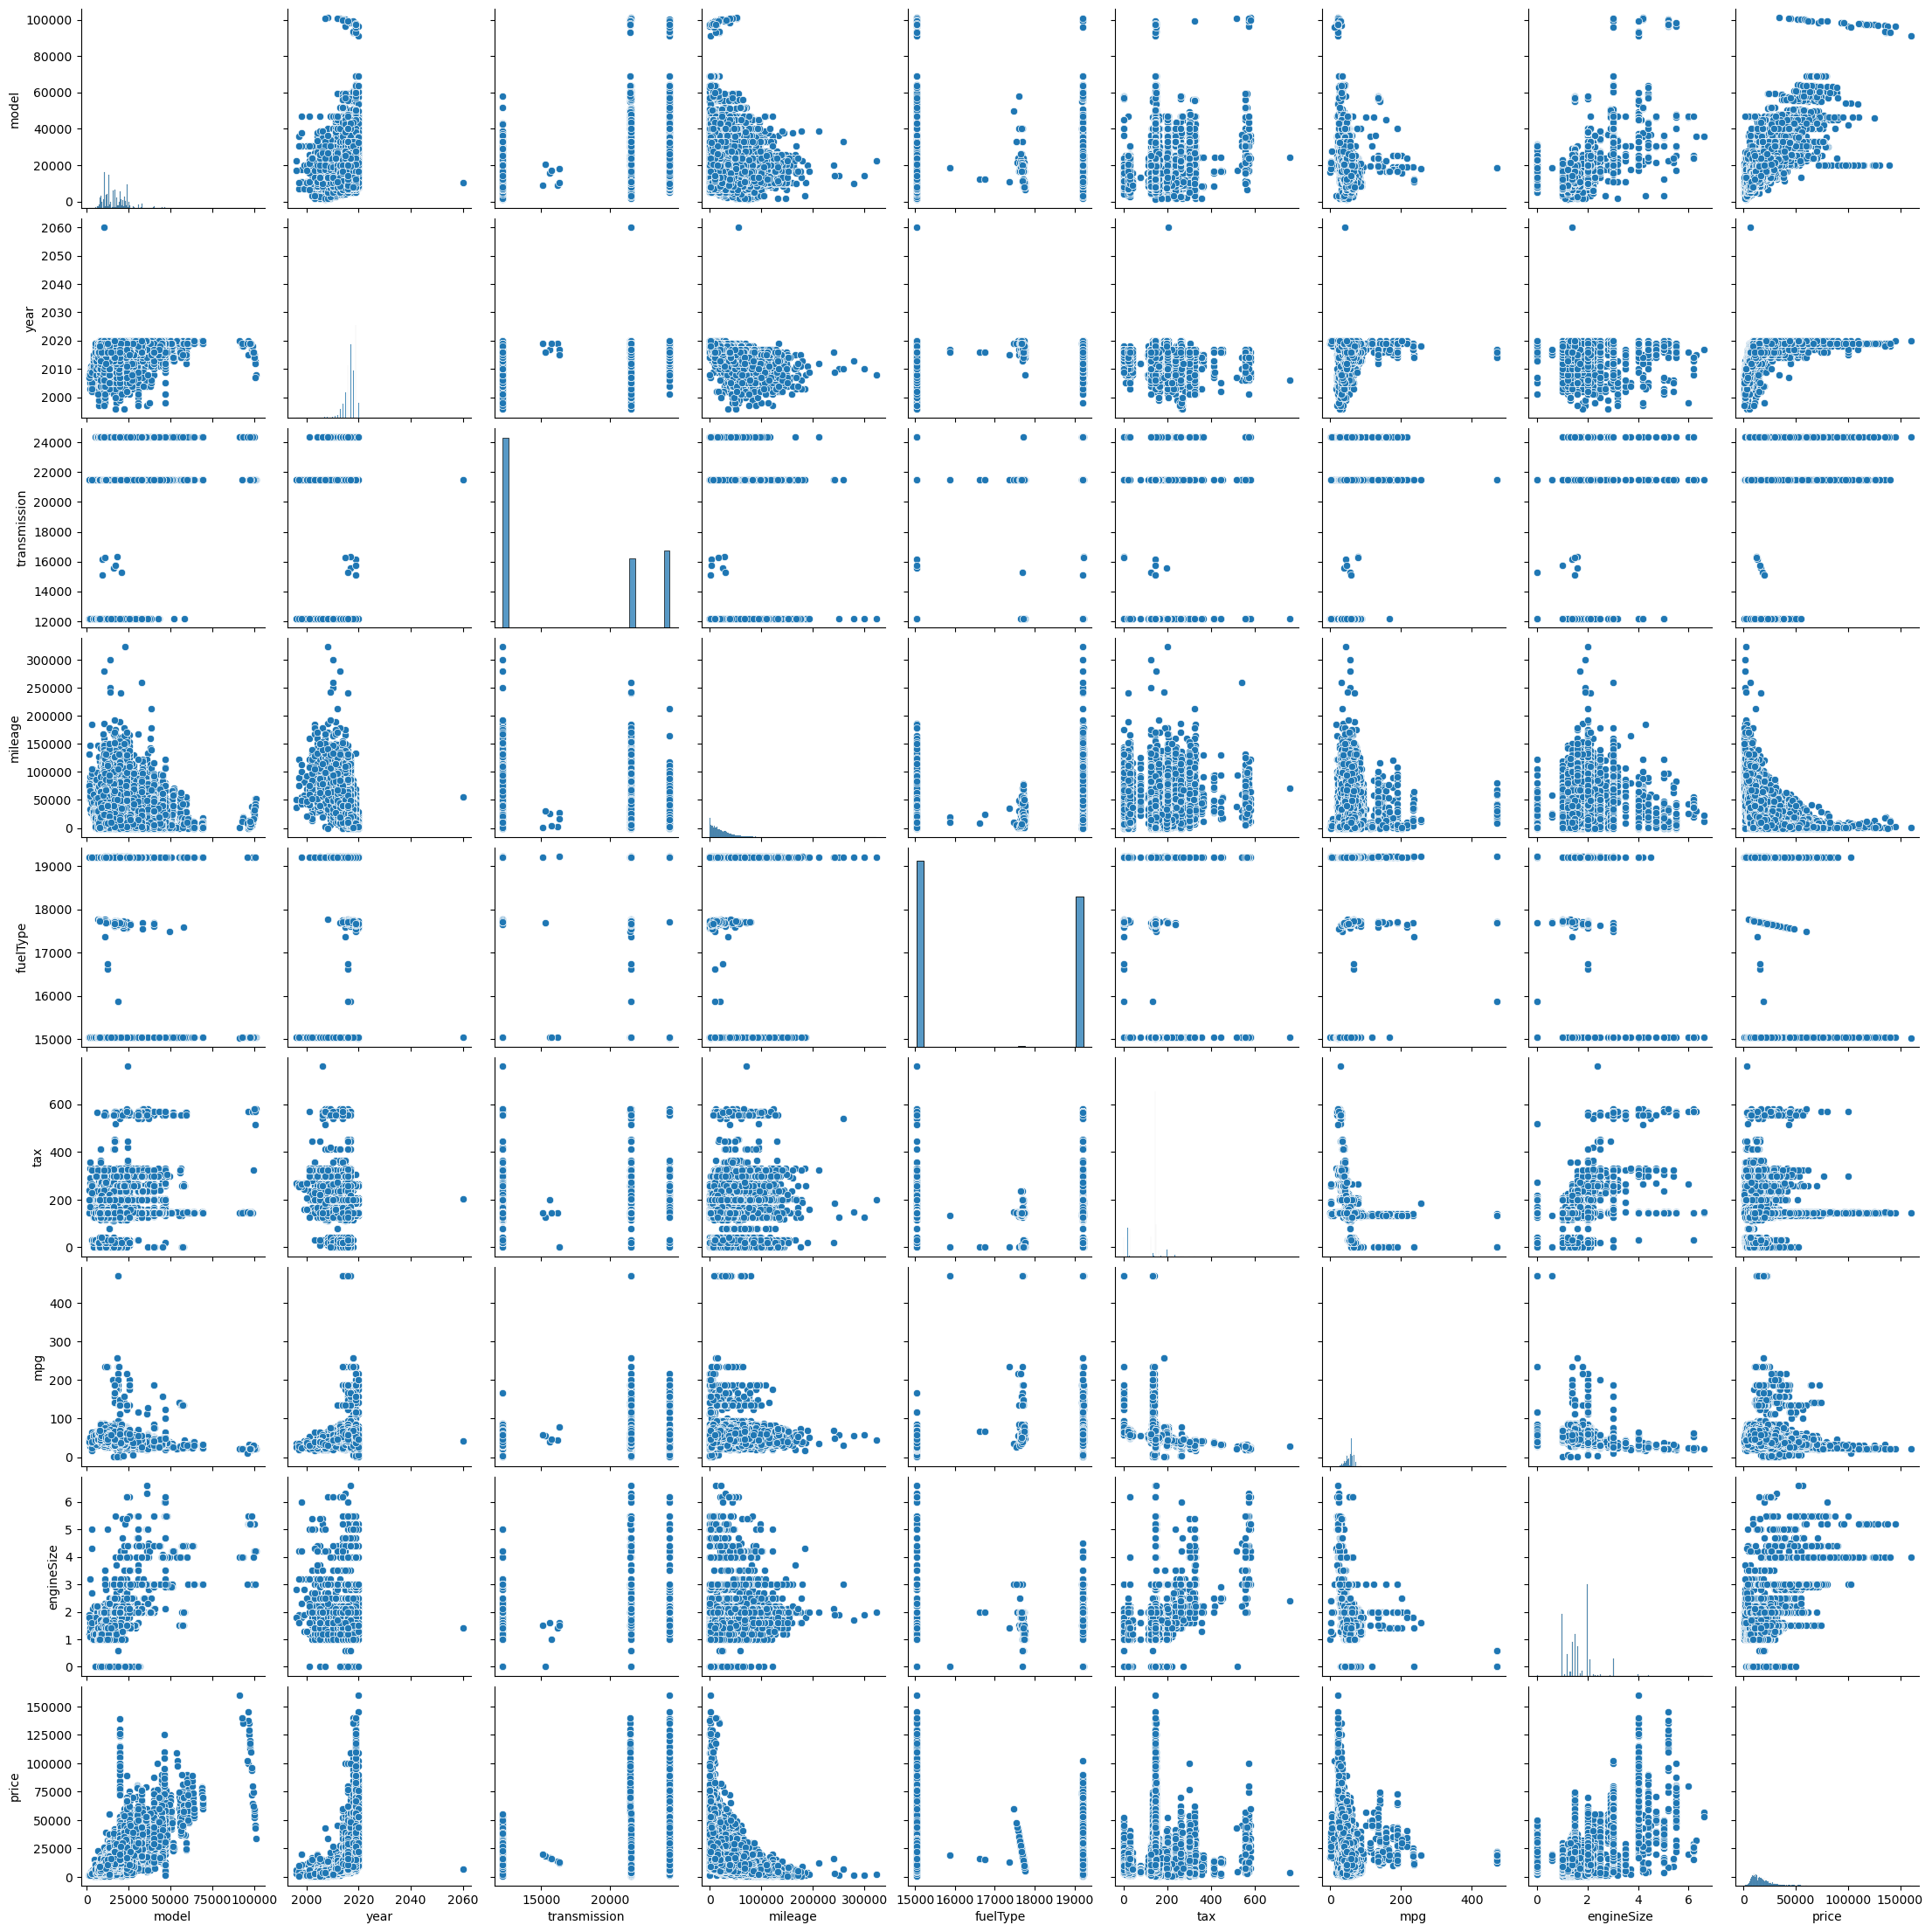

In [141]:
sns.pairplot(full_df3)

C:\Users\User\AppData\Local\Temp\ipykernel_8804\3695426550.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  full_df3 = full_df3[z_mask]


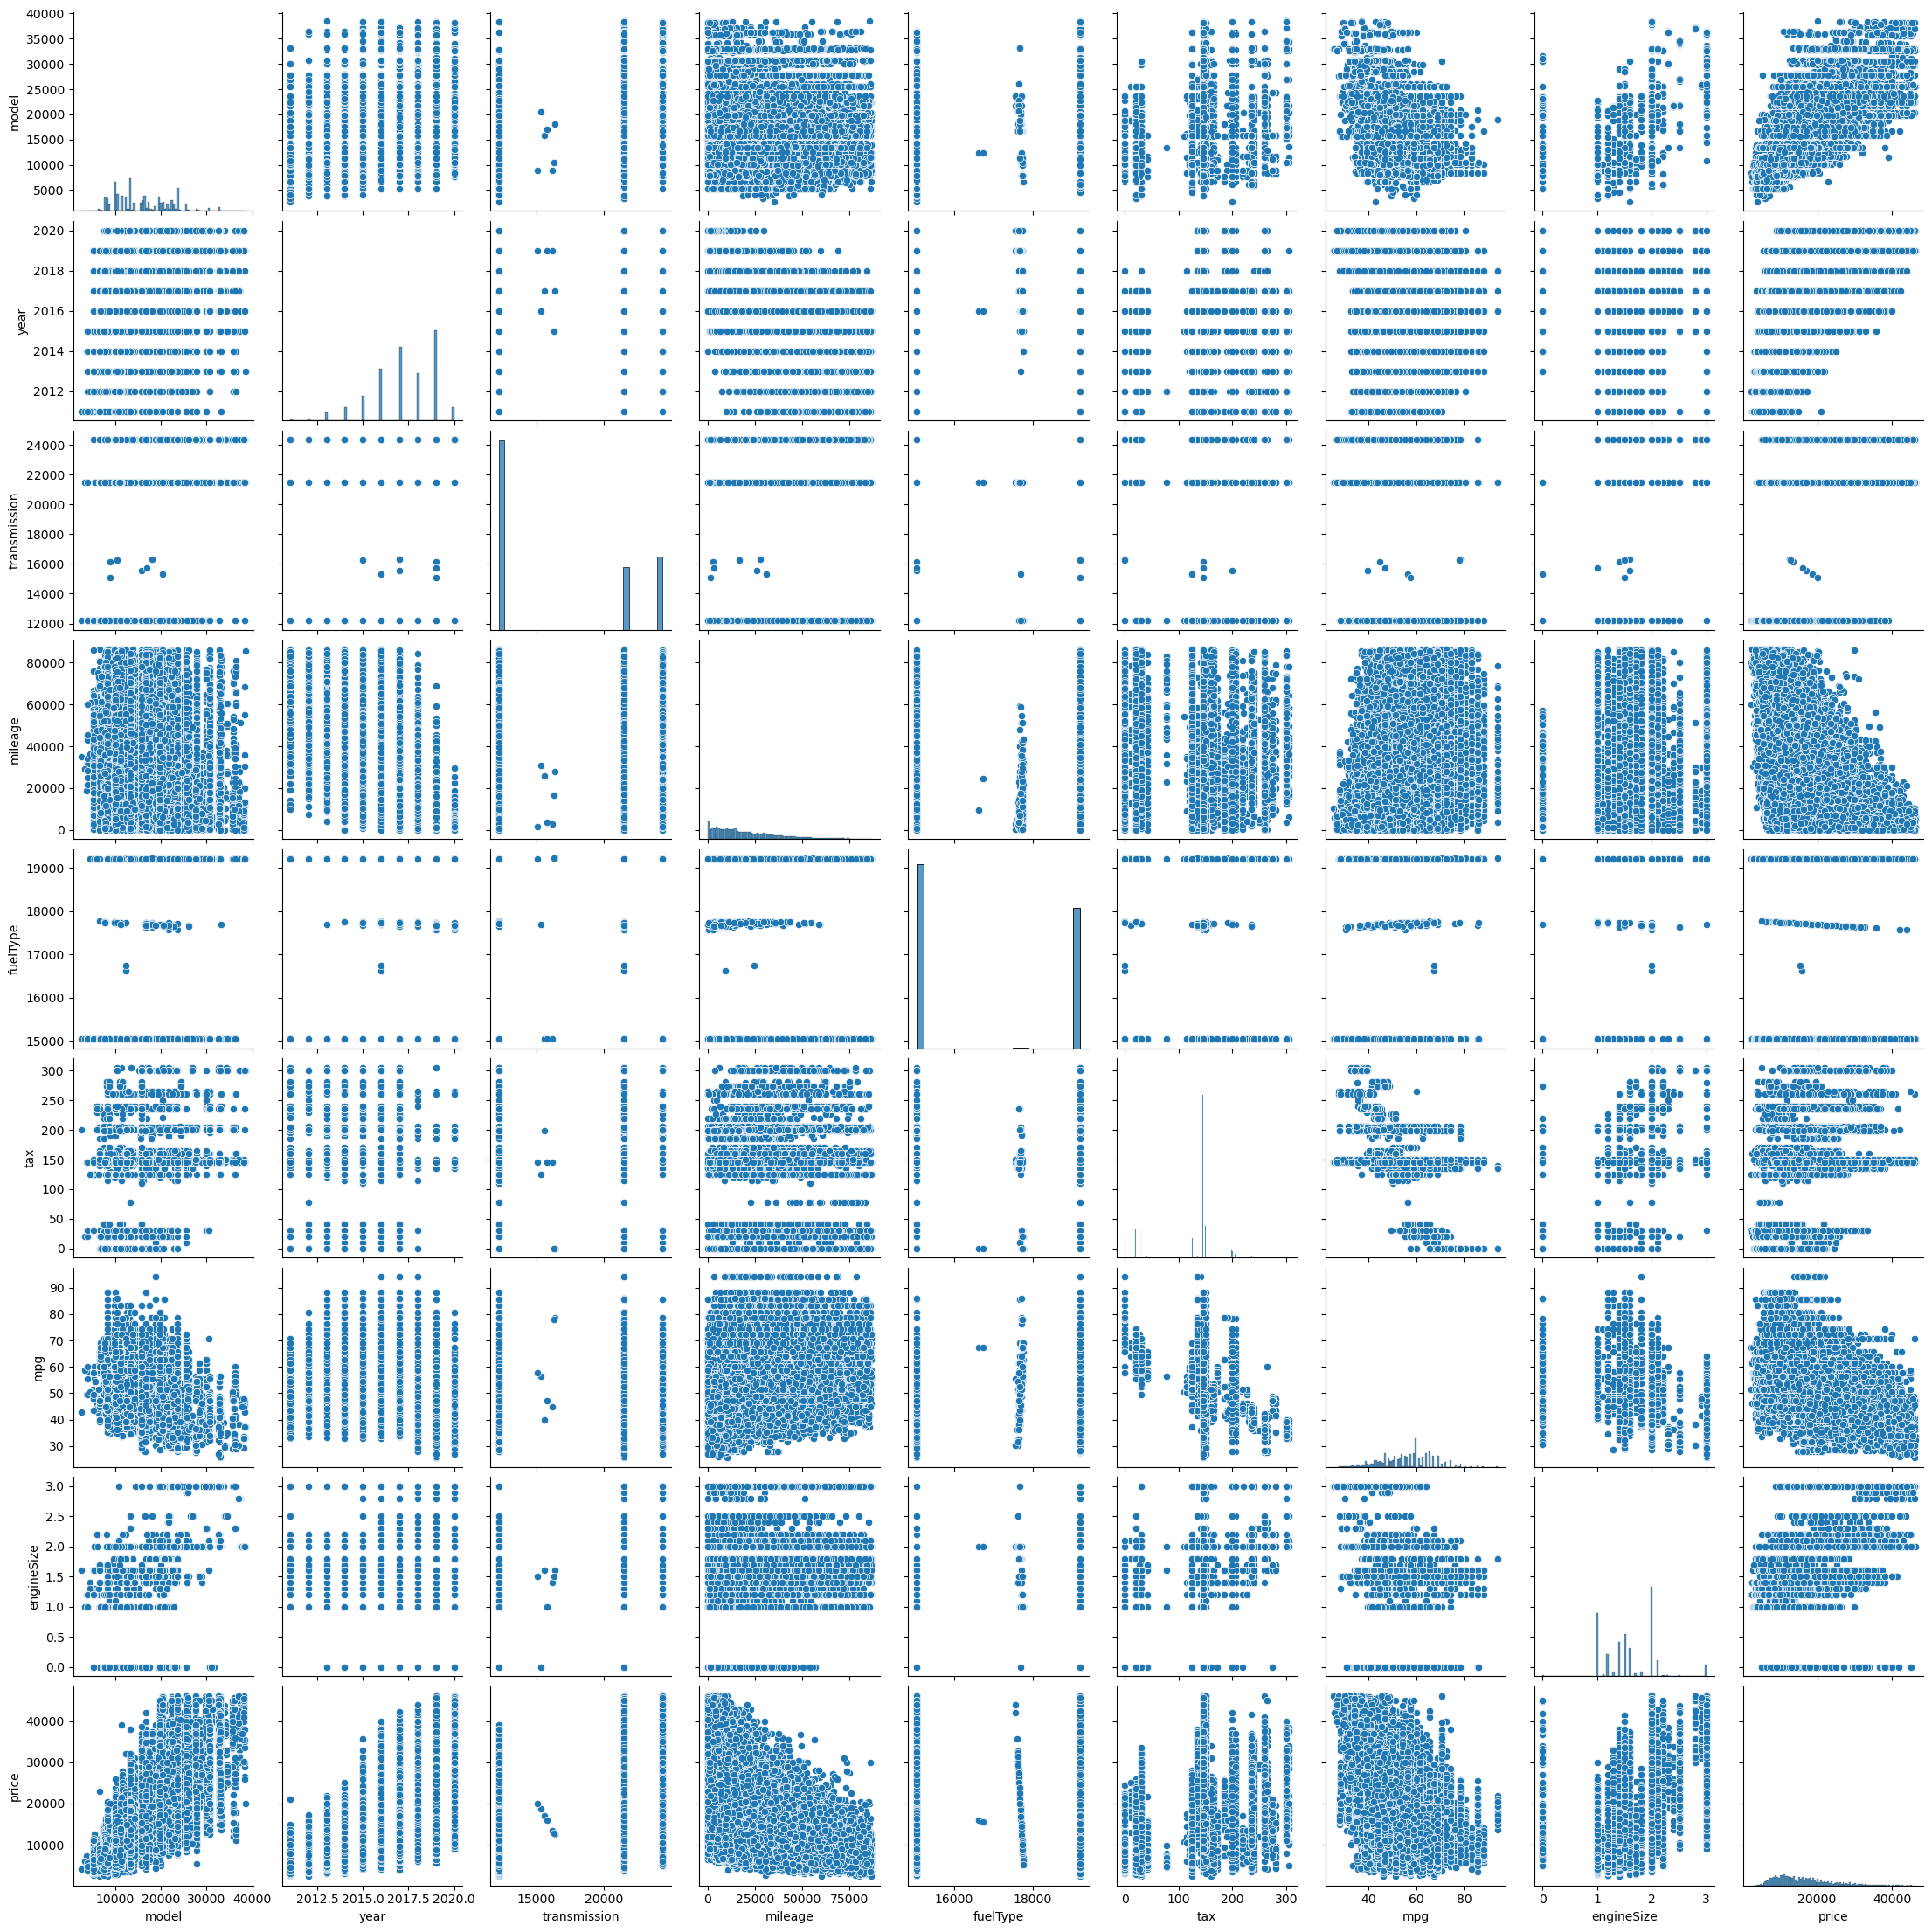

In [148]:
z_mask = (np.abs(z3) < 3).all(axis = 1) ##удалим выбросы во всем датафрейме (есть хотя бы один False как следствие условия np.abs(z) < 3)
 
full_df3 = full_df3[z_mask]
sns.pairplot(full_df3)

In [143]:
X = full_df3.drop('price', axis=1)

In [144]:
y=full_df3['price']

In [145]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True)

In [146]:
# Обучаем модель
model_lin = LinearRegression()
model_lin.fit(X_train3, y_train3)

# Предсказание
y_pred_lin = model_lin.predict(X_test3)

# Метрики
print("MSE:", mean_squared_error(y_test3, y_pred_lin))
print("R2:", r2_score(y_test3, y_pred_lin))

MSE: 7850882.439661805
R2: 0.8654784156999958


In [147]:
# Cлучвайный лес
model_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_forest.fit(X_train3, y_train3)
y_pred_forest = model_forest.predict(X_test3)

print("MSE:", mean_squared_error(y_test3, y_pred_forest))
print("R2:", r2_score(y_test3, y_pred_forest))

MSE: 19325.850696607682
R2: 0.9996688596379282


In [149]:
importances = pd.Series(model_forest.feature_importances_, index=X_train3.columns)
print(importances.sort_values(ascending=False).head(10))

model           0.436547
fuelType        0.265148
year            0.159646
transmission    0.089541
engineSize      0.048367
mpg             0.000294
tax             0.000268
mileage         0.000189
dtype: float64


In [150]:
from sklearn.inspection import permutation_importance

In [151]:
result = permutation_importance(model_forest, X_test3, y_test3, n_repeats=10, random_state=42)

In [152]:
result

{'importances_mean': array([8.23710685e-02, 1.33506231e-02, 3.25403154e-01, 5.45065038e-04,
        9.13540302e-01, 3.92419521e-04, 9.90623683e-04, 2.28791907e-02]),
 'importances_std': array([2.38111550e-03, 9.46906890e-04, 3.76373030e-03, 6.92793746e-05,
        1.12200696e-02, 3.03505184e-05, 8.05522074e-05, 1.27632062e-03]),
 'importances': array([[8.22194622e-02, 8.21936851e-02, 8.36832774e-02, 8.09919764e-02,
         7.72594997e-02, 8.19572226e-02, 8.03572669e-02, 8.59669837e-02,
         8.41411234e-02, 8.49401874e-02],
        [1.35915251e-02, 1.37898316e-02, 1.30445706e-02, 1.24052590e-02,
         1.16991279e-02, 1.47533191e-02, 1.44554173e-02, 1.37754281e-02,
         1.21651250e-02, 1.38266269e-02],
        [3.21729903e-01, 3.30764800e-01, 3.21961144e-01, 3.29142524e-01,
         3.22466190e-01, 3.25375351e-01, 3.31597600e-01, 3.20809058e-01,
         3.23466162e-01, 3.26718813e-01],
        [4.59853136e-04, 5.79783588e-04, 5.11536891e-04, 6.37337499e-04,
         4.024161

In [153]:
feature_names=X_test3.columns
feature_names

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

In [154]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": result.importances_mean, ## Cреднее падение качества модели
    "importance_std": result.importances_std ## Cтандартное отклонение важности
}).sort_values("importance_mean", ascending=False)
importance_df

,feature,importance_mean,importance_std
4,fuelType,0.913540,0.011220
2,transmission,0.325403,0.003764
0,model,0.082371,0.002381
7,engineSize,0.022879,0.001276
1,year,0.013351,0.000947
6,mpg,0.000991,0.000081
3,mileage,0.000545,0.000069
5,tax,0.000392,0.000030


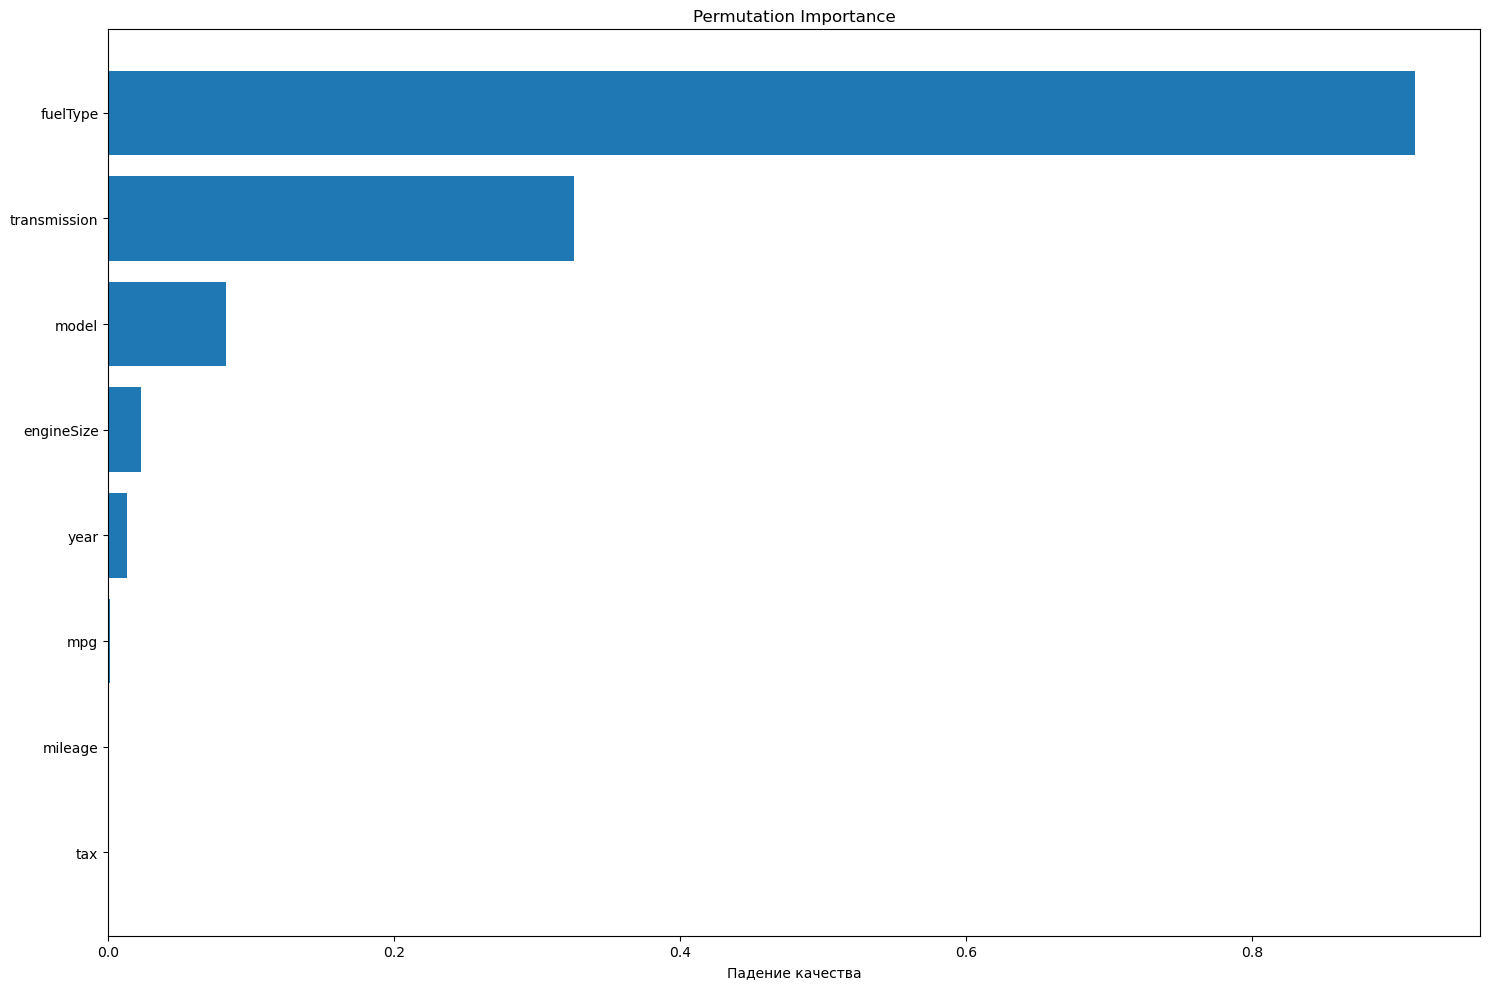

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.barh(importance_df["feature"], importance_df["importance_mean"])
plt.xlabel("Падение качества")
plt.title("Permutation Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [156]:
## Для общенго датасета наиболее влияемым параметром оказался fuel type - правда и отклонение у него получилось болше всех

In [157]:
## Строим модель стекинга

In [158]:
from sklearn.ensemble import StackingRegressor

In [159]:
##Стекинг
stack_model = StackingRegressor(
    estimators=[
        ("cat", model3),
        ("lin", model_lin),
        ("for", model_forest),
    ],
    final_estimator=LinearRegression(),
    passthrough=False,
    cv=5)

In [160]:
##Обучаем
stack_model.fit(X_train3, y_train3)

##Предсказываем
y_pred = stack_model.predict(X_test3)

##Метрики
mse = mean_squared_error(y_test3, y_pred)
r2 = r2_score(y_test3, y_pred)

print(f"MSE: {mse}")
print(f"R2: {r2}")

0:	learn: 3861.3230758	total: 5.92ms	remaining: 5.91s
100:	learn: 229.7370666	total: 525ms	remaining: 4.67s
200:	learn: 157.7041231	total: 1.08s	remaining: 4.29s
300:	learn: 130.5460407	total: 1.6s	remaining: 3.71s
400:	learn: 113.9559576	total: 2.11s	remaining: 3.15s
500:	learn: 103.9376863	total: 2.61s	remaining: 2.6s
600:	learn: 97.8149945	total: 3.13s	remaining: 2.08s
700:	learn: 93.1102204	total: 3.63s	remaining: 1.55s
800:	learn: 89.0872791	total: 4.14s	remaining: 1.03s
900:	learn: 86.1505460	total: 4.65s	remaining: 511ms
999:	learn: 83.2165870	total: 5.15s	remaining: 0us
0:	learn: 3836.8661514	total: 4.74ms	remaining: 4.73s
100:	learn: 214.1237112	total: 457ms	remaining: 4.07s
200:	learn: 149.1899426	total: 937ms	remaining: 3.72s
300:	learn: 122.2349611	total: 1.4s	remaining: 3.26s
400:	learn: 107.0244972	total: 1.85s	remaining: 2.77s
500:	learn: 97.2970873	total: 2.3s	remaining: 2.29s
600:	learn: 90.3973001	total: 2.74s	remaining: 1.82s
700:	learn: 85.7620873	total: 3.19s	remai